# 1×4 MMI power splitter in BeamZ

This BeamZ-native workflow recreates the geometry, source, monitor, spectral analysis, and length/width sweep of Tidy3D's [1×4 MMI power-splitter example](https://www.flexcompute.com/tidy3d/examples/notebooks/MMI1x4/). The device is a 3D Si–GaN–Si slot-waveguide MMI at 1550 nm.

The normal notebook runs the complete 3×3 parameter sweep. `BEAMZ_DOCS_TEST=1` activates a small single-point configuration for automated validation.

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

import beamz as bz
from beamz.analysis import mode_data_to_dataframe
from beamz.analysis.plotting import plot_mode_field_components

test_mode = os.environ.get("BEAMZ_DOCS_TEST") == "1"
execution_backend = "jax" if test_mode else "cuda_streamed"
um = bz.um

BeamZ 0.5.0 | reduced test mode: False


## 1. Materials and design parameters

The parameters match the reference example: a 5 µm-wide MMI, 11.2 µm initial length, 0.4 µm access waveguides, and a 0.1 µm GaN slot between 0.3 µm silicon layers.

In [2]:
n_si = 3.48
n_gan = 2.305
n_sio2 = 1.444
mat_si = bz.Material(permittivity=n_si**2)
mat_gan = bz.Material(permittivity=n_gan**2)
mat_sio2 = bz.Material(permittivity=n_sio2**2)

W_MMI = 5.0 * um
L_MMI = 11.2 * um
g1 = 0.9 * um
W1 = 0.4 * um
W2 = 0.8 * um
L1 = 2.0 * um
L2 = 5.0 * um
H_SI = 0.3 * um
H_GAN = 0.1 * um

lambda0 = 1.55 * um
freq0 = bz.LIGHT_SPEED / lambda0
wavelengths = np.linspace(1.50, 1.60, 3 if test_mode else 21) * um
freqs = bz.LIGHT_SPEED / wavelengths
fwidth = 0.5 * (np.max(freqs) - np.min(freqs))

buffer_x = 1.0 * um
buffer_y = 1.5 * um
slot_stack_thickness = 2 * H_SI + H_GAN
domain_depth = 5 * (2 * H_GAN + H_SI)
output_centers = np.array([-1.5, -0.5, 0.5, 1.5]) * (g1 + W1)
print("Output centerlines (µm):", output_centers / um)

Output centerlines (µm): [-1.95 -0.65  0.65  1.95]


## 2. Build a parameterized 3D MMI simulation

`make_sim()` is deliberately analogous to the reference notebook. It returns an immutable BeamZ `Simulation` and the named monitor geometry used later for analysis.

**API opportunity:** a public native MMI builder with named optical ports could replace the explicit rectangles and taper polygons below while preserving this transparent workflow.

In [3]:
def trapezoid(x0, x1, width0, width1, center_y=0.0):
    """Return a longitudinal taper polygon in the xy plane."""
    return (
        (x0, center_y - 0.5 * width0),
        (x1, center_y - 0.5 * width1),
        (x1, center_y + 0.5 * width1),
        (x0, center_y + 0.5 * width0),
    )


def make_sim(L_mmi, W_mmi, *, include_field=True):
    domain_length = L1 + L_mmi + L2 + 2 * buffer_x
    domain_width = W_mmi + 2 * buffer_y
    domain = (domain_length, domain_width, domain_depth)
    x_left = -0.5 * domain_length
    x_taper_in = x_left + buffer_x
    x_mmi_in = x_taper_in + L1
    x_mmi_out = x_mmi_in + L_mmi
    x_taper_out = x_mmi_out + L2

    # Si is continuous above and below the GaN slot. The GaN polygons are
    # added second, so the slot overrides the silicon material in its slab.
    silicon_polygons = [
        ((x_left, -W1 / 2), (x_taper_in, -W1 / 2),
         (x_taper_in, W1 / 2), (x_left, W1 / 2)),
        trapezoid(x_taper_in, x_mmi_in, W1, W2),
        ((x_mmi_in, -W_mmi / 2), (x_mmi_out, -W_mmi / 2),
         (x_mmi_out, W_mmi / 2), (x_mmi_in, W_mmi / 2)),
    ]
    for center_y in output_centers:
        silicon_polygons.extend(
            [
                trapezoid(x_mmi_out, x_taper_out, W2, W1, center_y),
                ((x_taper_out, center_y - W1 / 2), (0.5 * domain_length, center_y - W1 / 2),
                 (0.5 * domain_length, center_y + W1 / 2), (x_taper_out, center_y + W1 / 2)),
            ]
        )

    design = bz.Design(background=mat_sio2)
    for vertices in silicon_polygons:
        design += bz.Polygon(
            vertices=vertices, material=mat_si, depth=slot_stack_thickness,
            z=-0.5 * slot_stack_thickness, color="#d81b60",
        )
    for vertices in silicon_polygons:
        design += bz.Polygon(
            vertices=vertices, material=mat_gan, depth=H_GAN, z=-0.5 * H_GAN,
            color="#f6c85f",
        )

    steps_per_wavelength = 4 if test_mode else 12
    resolution = lambda0 / (steps_per_wavelength * n_si)
    grid_spec = bz.GridSpec.uniform(resolution)
    cpml_cells = 4 if test_mode else 12
    pml_thickness = cpml_cells * resolution
    source_time = bz.GaussianPulse(
        freq0=freq0, fwidth=fwidth, offset=0.5 if test_mode else 4.0,
    )
    mode_spec = bz.ModeSpec(
        num_modes=2, mode_index=0, target_neff=n_si, polarization="te",
    )
    source_x = x_left + 0.5 * buffer_x
    output_x = 0.5 * domain_length - 0.5 * buffer_x
    plane_size = (0.0, 5 * W1, domain_depth - 2 * pml_thickness)
    source = bz.ModeSource(
        center=(source_x, 0.0, 0.0), size=plane_size, direction="+",
        source_time=source_time, mode_spec=mode_spec,
    )
    flux_monitors = tuple(
        bz.FluxMonitor(
            center=(output_x, center_y, 0.0), size=(0.0, 3 * W1, domain_depth - 2 * pml_thickness),
            freqs=freqs, name=f"flux_{index}",
        )
        for index, center_y in enumerate(output_centers)
    )
    mode_monitors = (
        bz.ModeMonitor(
            center=(output_x, output_centers[1], 0.0),
            size=(0.0, 3 * W1, domain_depth - 2 * pml_thickness),
            freqs=freqs, mode_spec=mode_spec, name="mode_inner",
        ),
        bz.ModeMonitor(
            center=(output_x, output_centers[3], 0.0),
            size=(0.0, 3 * W1, domain_depth - 2 * pml_thickness),
            freqs=freqs, mode_spec=mode_spec, name="mode_outer",
        ),
    )
    field_monitor = bz.FieldMonitor(
        center=(0.0, 0.0, 0.0), size=(domain_length, domain_width, 0.0),
        freqs=[freq0], fields=("Ex", "Ey", "Ez", "Hx", "Hy", "Hz"), name="field",
    )
    monitors = (*flux_monitors, *mode_monitors, *((field_monitor,) if include_field else ()))
    simulation = bz.Simulation(
        domain=domain, design=design, sources=(source,), monitors=monitors,
        boundaries=(bz.PML(thickness=pml_thickness, formulation="cpml"),),
        grid_spec=grid_spec, run_time=(8 if test_mode else 5_000) / freq0,
        setup_device="cpu" if test_mode else "default",
    )
    return simulation, {
        "source": source, "output_x": output_x, "domain": domain,
        "pml_thickness": pml_thickness, "mode_spec": mode_spec,
    }

## 3. Initial design and source mode

As in the reference workflow, inspect both material cross sections and the local mode before launching the FDTD simulation.

3D grid: (545, 216, 68) | time steps: 365306


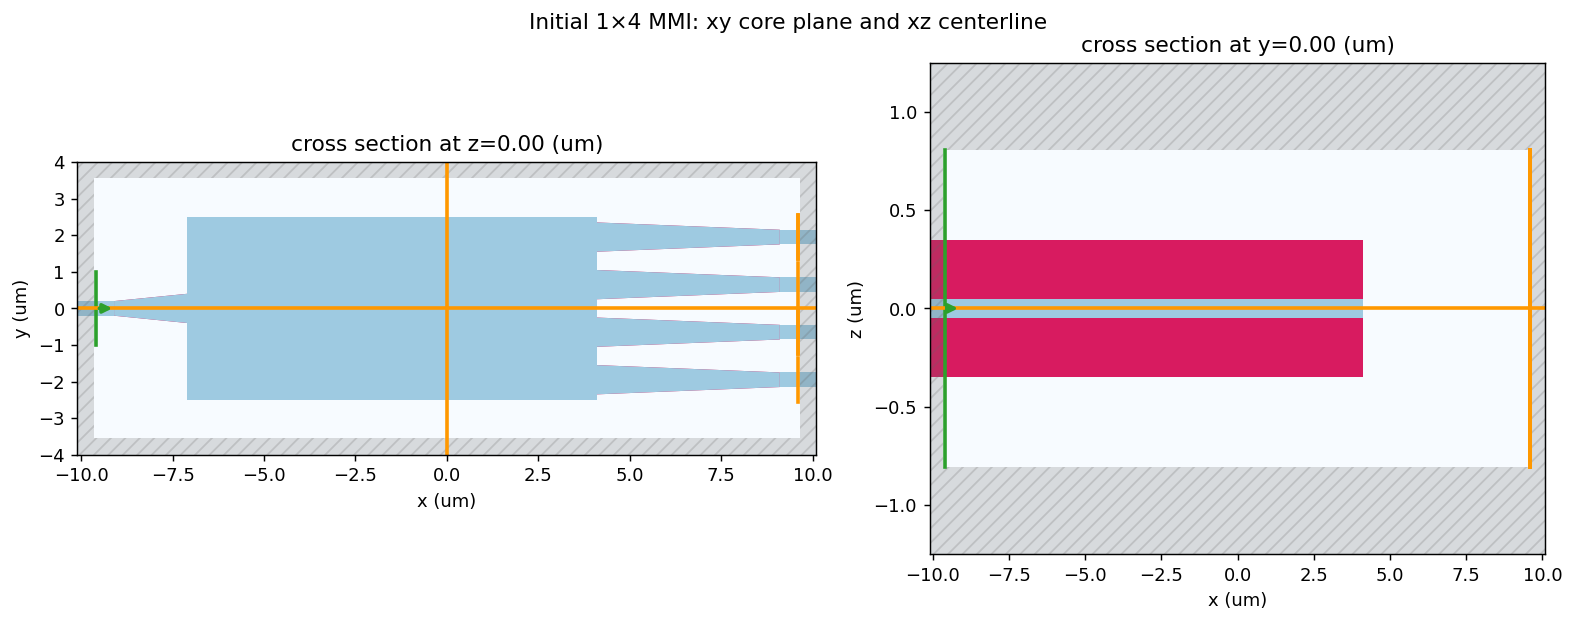

In [4]:
sim, setup = make_sim(L_MMI, W_MMI)
print(f"3D grid: {sim.grid.shape} | time steps: {sim.num_steps}")

fig, axes = sim.plot(
    z=0.0, y=0.0, figsize=(12, 4.5), width_ratios=(1.2, 1.0),
    source_markers=True, monitor_markers=True, show=False,
)
for axis in np.asarray(axes).flat:
    axis.grid(False)
fig.suptitle("Initial 1×4 MMI: xy core plane and xz centerline", y=1.03)
plt.show()

wavelength     n eff  k eff  loss (dB/cm)  mode area
f            mode_index                                                      
1.934145e+14 0                 1.55  2.651973    0.0           0.0   0.397128
             1                 1.55  2.362479    0.0           0.0   0.382592

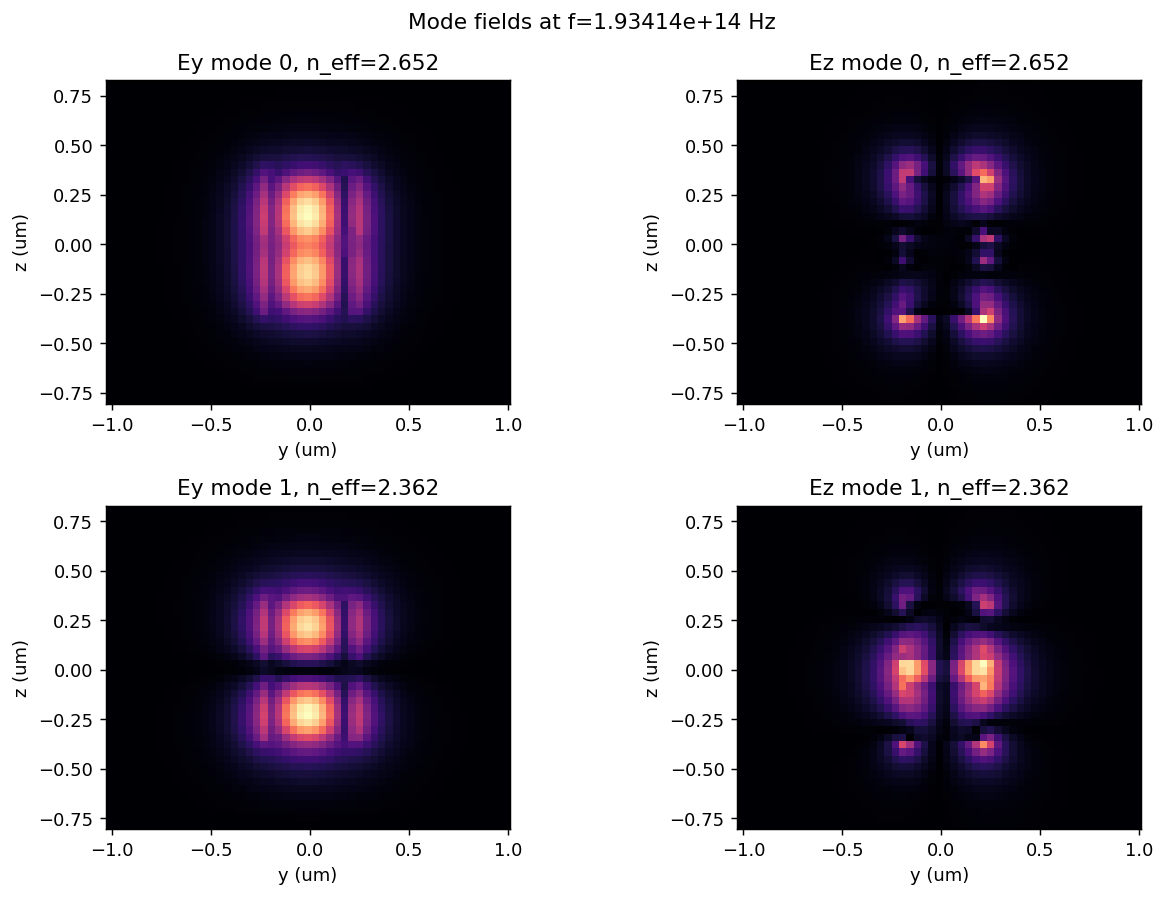

In [5]:
source_modes = setup["source"].solve_modes(sim, freqs=[freq0])
display(mode_data_to_dataframe(source_modes))

fig, axes, neffs = plot_mode_field_components(
    source_modes, field_names=("Ey", "Ez"), mode_indices=(0, 1), val="abs",
    f=freq0, figsize=(10, 7), show=False,
)
for axis in np.asarray(axes).flat:
    axis.grid(False)
plt.show()

# API opportunity: a `Simulation.solve_modes(plane=...)` convenience method
# could make this preview read even closer to a Tidy3D ModeSolver call.

## 4. Run the initial design and inspect its response

BeamZ executes locally. With the optional direct CUDA component installed, `backend="cuda_streamed"` can be selected here; the portable notebook uses JAX in reduced test mode.

In [6]:
initial_results = sim.run(progress=True, backend=execution_backend)

* Compiling simulation...
* Running simulation: [####################] 100% (365306/365306 steps)
Simulation runtime: 817.21 s
GCUPS: 3.578
Launched power: 1 | backend: cuda_streamed


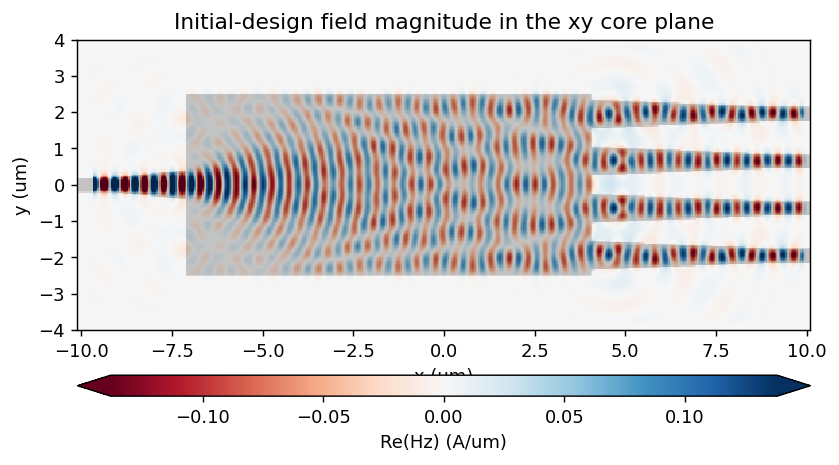

In [18]:
initial_results.plot_field("field", "Hz", frequency=freq0, val="real", cmap="RdBu", show_grid=False)
plt.title("Initial-design field magnitude in the xy core plane")
plt.show()

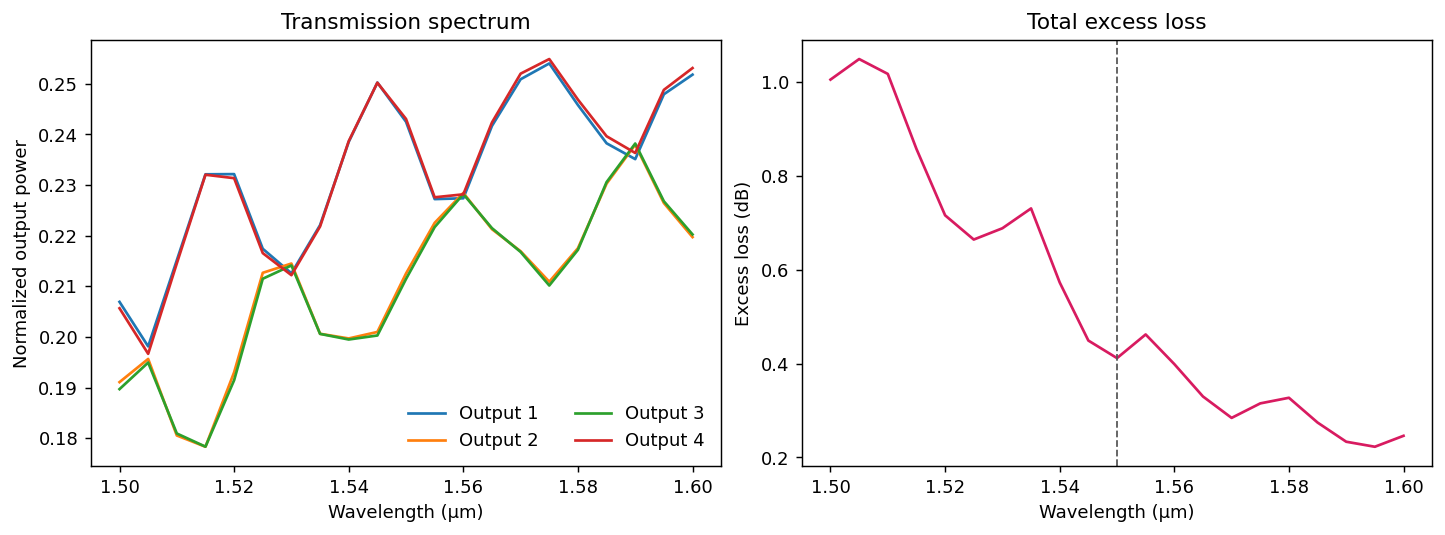

1550 nm: inner=0.212, outer=0.243, excess loss=0.412 dB


In [8]:
def splitter_metrics(results):
    launched = max(float(results.launched_power()), 1e-18)
    output_power = np.stack([
        np.maximum(np.asarray(results[f"flux_{index}"].flux, dtype=float), 0.0)
        for index in range(4)
    ]) / launched
    inner = 0.5 * (output_power[1] + output_power[2])
    outer = 0.5 * (output_power[0] + output_power[3])
    total = np.sum(output_power, axis=0)
    excess_loss_db = -10 * np.log10(np.maximum(total, 1e-12))
    imbalance = np.abs(inner - outer)
    return output_power, inner, outer, excess_loss_db, imbalance

output_power, inner_power, outer_power, excess_loss_db, imbalance = splitter_metrics(initial_results)
center_index = int(np.argmin(np.abs(wavelengths - lambda0)))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for index, power in enumerate(output_power):
    axes[0].plot(wavelengths / um, power, label=f"Output {index + 1}")
axes[0].set(xlabel="Wavelength (µm)", ylabel="Normalized output power", title="Transmission spectrum")
axes[0].legend(ncol=2, frameon=False)
axes[1].plot(wavelengths / um, excess_loss_db, color="#d81b60")
axes[1].axvline(lambda0 / um, color="0.35", ls="--", lw=1)
axes[1].set(xlabel="Wavelength (µm)", ylabel="Excess loss (dB)", title="Total excess loss")
for axis in axes:
    axis.grid(False)
plt.show()
print(f"1550 nm: inner={inner_power[center_index]:.3f}, outer={outer_power[center_index]:.3f}, excess loss={excess_loss_db[center_index]:.3f} dB")

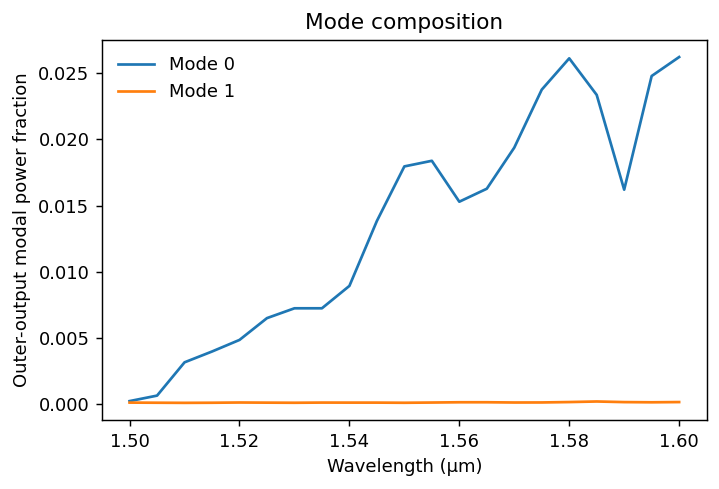

In [9]:
outer_mode_data = initial_results.mode("mode_outer")
forward_amps = np.asarray(outer_mode_data.amps.sel(direction="+"))
modal_fraction = np.abs(forward_amps) ** 2 / np.maximum(outer_power[:, None], 1e-12)

fig, ax = plt.subplots(figsize=(6, 3.8))
for mode_index in range(modal_fraction.shape[1]):
    ax.plot(wavelengths / um, modal_fraction[:, mode_index], label=f"Mode {mode_index}")
ax.set(xlabel="Wavelength (µm)", ylabel="Outer-output modal power fraction", title="Mode composition")
ax.legend(frameon=False)
ax.grid(False)
plt.show()

# API opportunity: `results.mode(name).power_fraction(direction="+")`
# would eliminate this explicit amplitude-to-power normalization.

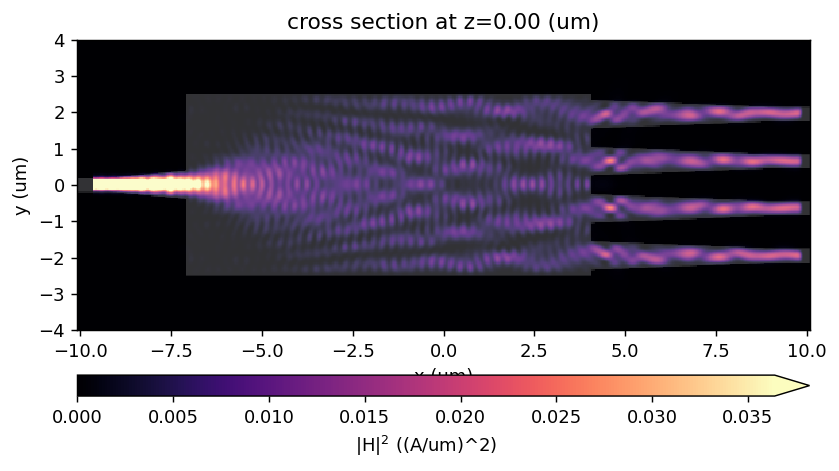

In [24]:
initial_results.plot_field("field", "H", frequency=freq0, val="abs^2", cmap="magma")
plt.show()